#  MNIST 훼손된 이미지 학습 : [총 10점]

-  주어진 코드란을 실행시키거나, 직접 작성한 코드를 실행시키면서 문제를 푸세요. 
-  <span style="color:red">모든 코드셀들을 수행시킨 결과물이 이 주피터 노트북에 나타나야 합니다. 코드 결과가 있는 주피터 노트북을 저장하여 제출하세요 .</span>



## Corrupted MNIST 데이터를 불러오는 코드들을 호출함

In [66]:
import numpy as np

train_images=np.load('train_images.npy')
train_labels=np.load('train_labels.npy')

test_images=np.load('test_images.npy')
test_labels=np.load('test_labels.npy')

In [68]:
print(train_images.shape,train_labels.shape)
print(test_images.shape,test_labels.shape)

(60000, 28, 28, 1) (60000,)
(10000, 28, 28, 1) (10000,)


## 그림의 내용을 보기 

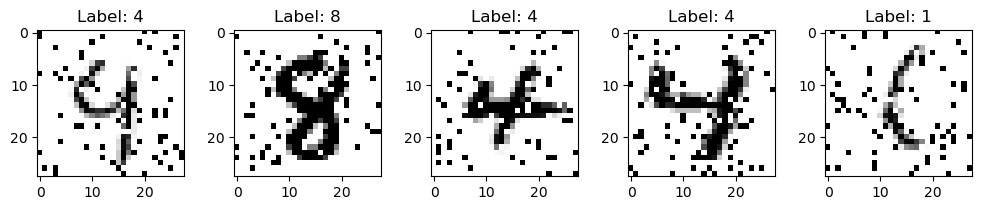

In [71]:
import matplotlib.pyplot as plt

random_indices = np.random.choice(len(train_images), size=5, replace=False)

# 그림 출력
plt.figure(figsize=(10, 2))  
for idx, i in enumerate(random_indices):
    plt.subplot(1, 5, idx + 1)  # 1행 5열 중 idx+1번째
    plt.imshow(train_images[i], cmap='binary')
    plt.title(f"Label: {train_labels[i]}")

plt.tight_layout()
plt.show()

# Q1 : 학생의 학번, 이름을 아래 코드를 통해 출력하시오 

In [73]:
print('학번= 21101206', ', 이름= 이동호')

학번= 21101206 , 이름= 이동호


## 데이터를 학습에 맞도록 크기를 변환
- 1. 각 픽셀의 크기를 $0\le f \le 255$ 에서 $0\le f \le 1$로 크기를 조정해 준다.
- 2. label을 one-hot encoding 을 시켜준다. (해당값을 1로, 그 나머지를 0으로 변환)

In [77]:
from keras.utils import to_categorical
 
train_images=train_images.astype('float32')/255
test_images=test_images.astype('float32')/255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [79]:
print(train_images.shape,train_labels.shape)
print(test_images.shape,test_labels.shape)

(60000, 28, 28, 1) (60000, 10)
(10000, 28, 28, 1) (10000, 10)


## Q2 : Hidden Layer가 4개인 Deep network 을 사용하여 학습할 경우 [총 3점]

- ### <span style="color:red">은닉층들의 노드 갯수는 좋은 training 학습결과를 주도록 설정하여라. 즉 Q3의 결과를 봐야 노드들의 갯수를 결정할 수 있음.</span> <br>
### (예:) 아래는 수업에서 DNN 예 (은닉층의 노드를 $(n_1, n_2, n_3) = (100, 50, 20) $)를 사용하는 경우 네트워크 구성<br>
이 모델을 model 이라 칭하는 경우, 
```python
from keras import models
from keras import layers
from keras.layers import Input

model=models.Sequential()
model.add(Input(shape=(28,28 )))# 새로운 tensorflow 버전에서 warning 을 없애기 위해 Input을 따로 입력
model.add(layers.Flatten()) # Neural Network에 입력하기 위해 2차원 배열을 1차원 배열로 flatten 시킴 
model.add(layers.Dense(100,activation=      ))
model.add(layers.Dense(50, activation=      ))
model.add(layers.Dense(20, activation=      ))
model.add(layers.Dense(10, activation=       ))
model.summary()

```
- 위 예제에서 각 layer의 activation function(활성화 함수)을 작성하지 않았습니다. 실제 코드구현에서는 각 layer의 activation function을 적절히 설정해야 합니다.
-  <span style="color:red">위의 예제와 똑같이 작성하면 점수 인정 없습니다. 은닉층의 갯수, 각 은닉층의 노드 갯수를 변화시키면서 학습 결과를 확인한 후, 가장 좋은 validation 결과를 주는 네트워크를 만들어 보세요.</span>

In [82]:
# 네트워크 구성을 아래에 작성하세요.  

from keras import models
from keras import layers
from keras.layers import Input
from keras.activations import gelu


model1 = models.Sequential()
model1.add(Input(shape=(28, 28)))
model1.add(layers.Flatten())
model1.add(layers.Dense(256, activation=gelu))
model1.add(layers.Dense(128, activation=gelu))
model1.add(layers.Dense(64, activation=gelu))
model1.add(layers.Dense(32, activation=gelu))
model1.add(layers.Dense(10, activation='softmax'))

model1.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 244,522 (955.16 KB)

 Trainable params: 244,522 (955.16 KB)

 Non-trainable params: 0 (0.00 B)

## Q3 : 아래의 코드란에, 위의 네트워크를 학습 시키시오. [3점]
- 1. learning_rate 를 적절히 조정한다. 
- 2. Optimizer와 loss함수를 적절하게 선택한다. (1점)
- 3. 미니배치의 개수는 100으로 고정하고, 총 에포크는 20 번으로 반복시킨다. (1점) 
- 4. Validation 데이터는 test 데이터를 사용하시오. (1점)


In [85]:
# 위 Q2에서 구성한 네트워크 학습 (여기서, 위에서 구성된 네트워크 이름이 model 이라 가정하였음. 본인의 모델 이름에 맞게 바꿀것)
# 아래 예시코드를 적절히 변형하고, 빈칸을 채울 것

from keras.optimizers import Adam

model1.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

result = model1.fit(train_images, train_labels,
                   epochs=20,
                   batch_size=100,
                   verbose=2,
                   validation_data=(test_images, test_labels))


Epoch 1/20
600/600 - 4s - 6ms/step - accuracy: 0.8648 - loss: 0.4337 - val_accuracy: 0.9265 - val_loss: 0.2337
Epoch 2/20
600/600 - 2s - 4ms/step - accuracy: 0.9484 - loss: 0.1679 - val_accuracy: 0.9366 - val_loss: 0.2013
Epoch 3/20
600/600 - 2s - 4ms/step - accuracy: 0.9718 - loss: 0.0903 - val_accuracy: 0.9434 - val_loss: 0.1852
Epoch 4/20
600/600 - 2s - 4ms/step - accuracy: 0.9855 - loss: 0.0478 - val_accuracy: 0.9466 - val_loss: 0.1920
Epoch 5/20
600/600 - 2s - 4ms/step - accuracy: 0.9899 - loss: 0.0310 - val_accuracy: 0.9442 - val_loss: 0.2147
Epoch 6/20
600/600 - 2s - 4ms/step - accuracy: 0.9908 - loss: 0.0272 - val_accuracy: 0.9483 - val_loss: 0.2198
Epoch 7/20
600/600 - 2s - 4ms/step - accuracy: 0.9926 - loss: 0.0215 - val_accuracy: 0.9402 - val_loss: 0.2781
Epoch 8/20
600/600 - 2s - 4ms/step - accuracy: 0.9944 - loss: 0.0179 - val_accuracy: 0.9485 - val_loss: 0.2563
Epoch 9/20
600/600 - 3s - 4ms/step - accuracy: 0.9931 - loss: 0.0197 - val_accuracy: 0.9411 - val_loss: 0.2797
E

## Q4: 테스트 정밀도 확인하고, 시각적으로 학습 결과 확인 [1점]
- 아래의 코드를 실행시켜 결과를 출력하시오. (아래의 경우에 네트워크 이름이 model 으로 설정되어 있음. 본인이 이름붙인 네트워크 모델 이름을 사용할 것.

In [87]:
test_loss, test_acc = model1.evaluate(test_images, test_labels)
print('test accuracy=',test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9372 - loss: 0.3580
test accuracy= 0.9484000205993652


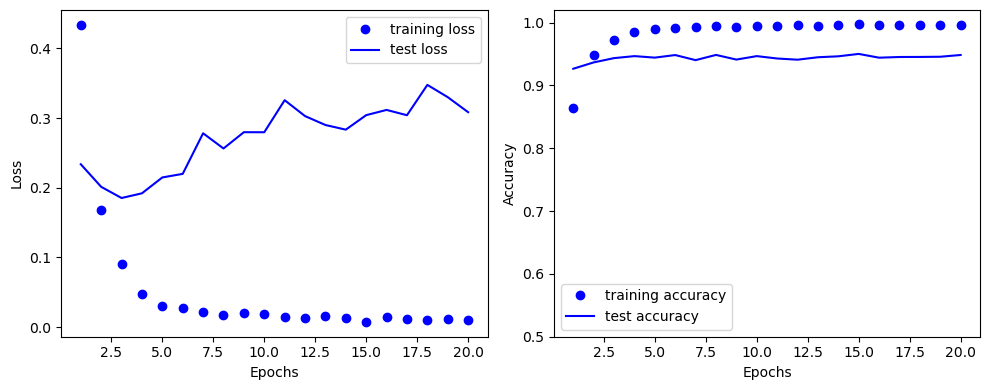

In [88]:
history_dict= result.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
epochs = range(1, len(loss)+1)
plt.figure(figsize=(10, 4))
plt.subplot(121)

plt.plot(epochs, loss, 'bo',label='training loss')
plt.plot(epochs, val_loss, 'b', label='test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss') 
plt.legend()
plt.subplot(122)

plt.plot(epochs, accuracy, 'bo',label='training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim((0.5,1.02)) 
plt.legend()

plt.tight_layout()
plt.show()

## Q5 : 위의 결과를 보면,  오버피팅이 심각할 것임.
## 수업시간에 배운 내용을 바탕으로 오버피팅을 최소화 할 것 [3점]
- 1. 아래의 코드란에 코드 작성
- 2. 오버피팅이 어느정도 감소하였는지, 그림(위의 그림과 같이) 결과로 보여줄 것

Epoch 1/20
600/600 - 4s - 7ms/step - accuracy: 0.7975 - loss: 1.1349 - val_accuracy: 0.9124 - val_loss: 0.6732
Epoch 2/20
600/600 - 2s - 4ms/step - accuracy: 0.9057 - loss: 0.6490 - val_accuracy: 0.9308 - val_loss: 0.5298
Epoch 3/20
600/600 - 2s - 4ms/step - accuracy: 0.9253 - loss: 0.5298 - val_accuracy: 0.9397 - val_loss: 0.4552
Epoch 4/20
600/600 - 2s - 4ms/step - accuracy: 0.9326 - loss: 0.4816 - val_accuracy: 0.9425 - val_loss: 0.4387
Epoch 5/20
600/600 - 2s - 4ms/step - accuracy: 0.9385 - loss: 0.4529 - val_accuracy: 0.9460 - val_loss: 0.4148
Epoch 6/20
600/600 - 2s - 4ms/step - accuracy: 0.9405 - loss: 0.4345 - val_accuracy: 0.9497 - val_loss: 0.4061
Epoch 7/20
600/600 - 2s - 4ms/step - accuracy: 0.9435 - loss: 0.4253 - val_accuracy: 0.9429 - val_loss: 0.4192
Epoch 8/20
600/600 - 2s - 4ms/step - accuracy: 0.9429 - loss: 0.4233 - val_accuracy: 0.9473 - val_loss: 0.4076
Epoch 9/20
600/600 - 2s - 4ms/step - accuracy: 0.9467 - loss: 0.4090 - val_accuracy: 0.9511 - val_loss: 0.3935
E

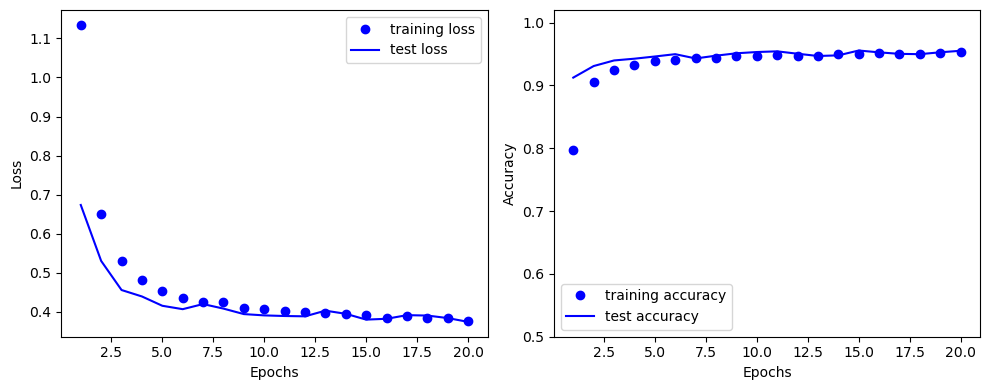

In [90]:
from keras import models, layers, Input, regularizers
from keras.activations import gelu
from keras.optimizers import Adam
import matplotlib.pyplot as plt

# 모델 정의
model2 = models.Sequential()
model2.add(Input(shape=(28, 28)))
model2.add(layers.Flatten())
model2.add(layers.Dense(256, activation=gelu, kernel_regularizer=regularizers.l2(0.001)))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(128, activation=gelu, kernel_regularizer=regularizers.l2(0.001)))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(64, activation=gelu, kernel_regularizer=regularizers.l2(0.001)))
model2.add(layers.Dropout(0.3))
model2.add(layers.Dense(32, activation=gelu, kernel_regularizer=regularizers.l2(0.001)))
model2.add(layers.Dense(10, activation='softmax'))

# 컴파일
model2.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# 학습
result = model2.fit(train_images, train_labels,
                         epochs=20,
                         batch_size=100,
                         verbose=2,
                         validation_data=(test_images, test_labels))

# 테스트 성능
test_loss_q5, test_acc_q5 = model2.evaluate(test_images, test_labels)
print("Q5 Test Accuracy:", test_acc_q5)

# 시각화
history_dict = result.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(epochs, loss, 'bo', label='training loss')
plt.plot(epochs, val_loss, 'b', label='test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(122)
plt.plot(epochs, accuracy, 'bo', label='training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim((0.5, 1.02))
plt.legend()
plt.tight_layout()
plt.show()


In [95]:
#Dropout과 L2 정규화를 적용한 model2에서는 test loss가 점차 안정되며 상승폭이 억제되는 것을 확인할 수 있다.  
#또한 training accuracy와 test accuracy의 차이가 줄어들어, 오버피팅이 개선된 양상을 보인다.

# 수고하셨습니다 !